<a href="https://colab.research.google.com/github/AmitojSinghChawla/DataScience/blob/main/Accredian_Home_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

In [3]:
dataset.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
dataset.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [5]:
dataset.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


*We have healthy data with 0 null values in any of the given columns, hence no imputation or dropping is needed*


In [11]:
dataset.duplicated().sum()

np.int64(0)

*No duplicates also inside the data*


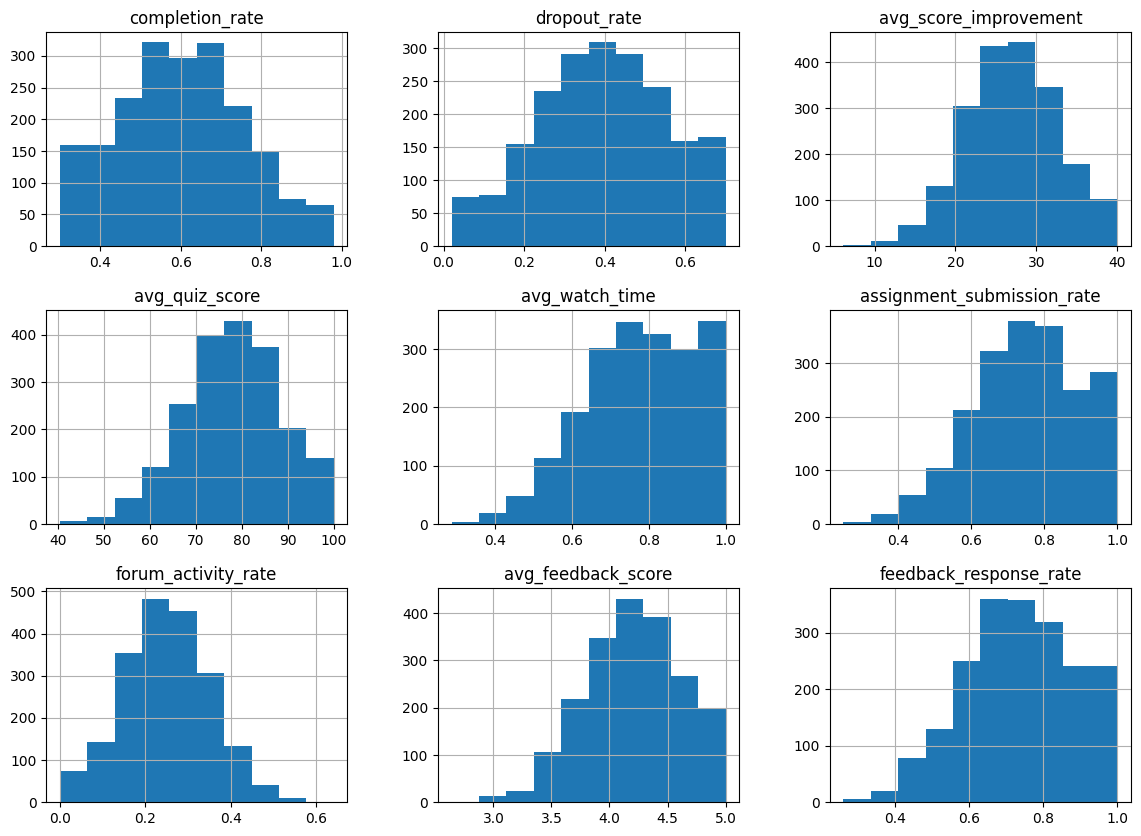

In [ ]:
dataset[['completion_rate','dropout_rate','avg_score_improvement',
    'avg_quiz_score','avg_watch_time','assignment_submission_rate',
    'forum_activity_rate','avg_feedback_score','feedback_response_rate']].hist(figsize=(14,10))
plt.show()



In [ ]:
dataset[['completion_rate','dropout_rate','avg_score_improvement',
    'avg_quiz_score','avg_watch_time','assignment_submission_rate',
    'forum_activity_rate','avg_feedback_score','feedback_response_rate']].skew()

,0
completion_rate,0.109298
dropout_rate,-0.102811
avg_score_improvement,-0.003487
avg_quiz_score,-0.200492
avg_watch_time,-0.317859
assignment_submission_rate,-0.255980
forum_activity_rate,0.044511
avg_feedback_score,-0.172339
feedback_response_rate,-0.175486


All variables showed **low skew (|skew| < 0.35)**, indicating fairly symmetric distributions with no major outlier batches. This supports using mean-based aggregation without needing outlier-robust alternatives like median

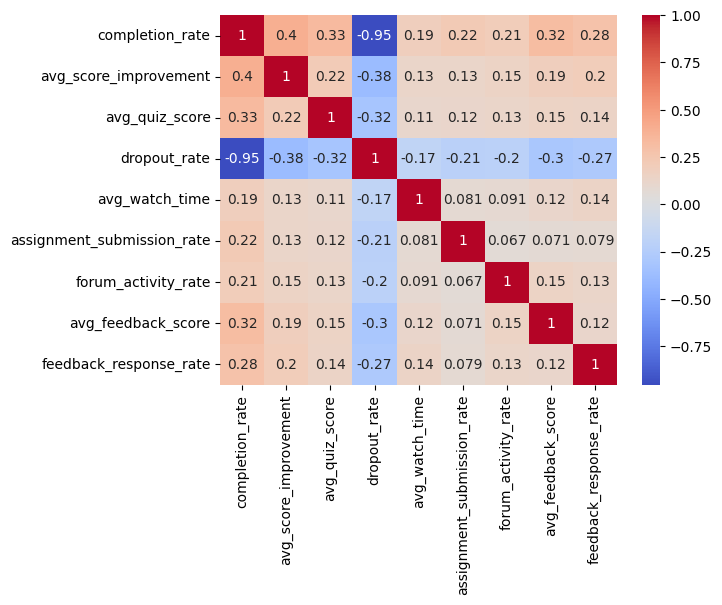

In [ ]:
corr = dataset.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()



**completion_rate** and dropout_rate showed a correlation of -0.95, indicating they capture almost the same signal. so keeping only completion_rate to avoid redundancy in the effectiveness score and model features

In [14]:
dataset.groupby('instructor_id').size().describe()


,0
count,120.000000
mean,16.666667
std,4.582270
min,7.000000
25%,13.750000
50%,17.000000
75%,19.000000
max,31.000000


In [15]:
batch_counts = dataset.groupby('instructor_id').size().sort_values(ascending=False)
print(batch_counts.head())
print(batch_counts.tail())

instructor_id
I_062    31
I_101    27
I_051    26
I_033    26
I_099    26
dtype: int64
instructor_id
I_031    8
I_041    8
I_077    8
I_091    8
I_102    7
dtype: int64


Batch counts range smoothly from 7 (I_102) to 31 (I_062), with no instructors having extremely low counts that would make their aggregated score unreliable. This supports using simple mean aggregation across all instructors without special-casing low-batch cases

In [16]:
# Step 2: Define Instructor Effectiveness Score

metrics = ['completion_rate', 'avg_score_improvement', 'assignment_submission_rate', 'avg_feedback_score']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(dataset[metrics]), columns=metrics)

weights = {
    'completion_rate': 0.3,             # outcome
    'avg_score_improvement': 0.3,       # outcome
    'assignment_submission_rate': 0.2,  # engagement
    'avg_feedback_score': 0.2           # feedback
}

dataset['effectiveness_score'] = sum(df_norm[m] * w for m, w in weights.items())

dataset[['completion_rate', 'avg_score_improvement', 'assignment_submission_rate', 'avg_feedback_score', 'effectiveness_score']].head()

,completion_rate,avg_score_improvement,assignment_submission_rate,avg_feedback_score,effectiveness_score
0,0.300000,14.225955,0.790918,3.766211,0.311119
1,0.657220,22.871110,0.998566,5.000000,0.705366
2,0.300000,16.087517,0.807298,3.517386,0.310911
3,0.639507,24.260687,0.544555,4.207578,0.521468
4,0.527302,31.081556,0.865885,4.426230,0.636778


### Reasoning for Selecting Features to Construct an Instructor Effectiveness Score

The following features were selected to evaluate instructor effectiveness:

1. **Completion Rate**  
   Completion rate indicates the proportion of students who successfully completed the course under a particular instructor. A higher completion rate may suggest that the instructor was effective in maintaining student engagement and supporting students throughout the course.

2. **Average Score Improvement**  
   Average score improvement is an important measure of instructor impact. Compared with the **average quiz score**, score improvement better captures the learning gain during the course and is more closely associated with the instructional process, whereas final scores may also be influenced by factors related to exam difficulty and assessment conditions.

3. **Assignment Submission Rate**  
   Assignment submission rate reflects the extent to which students actively participated in the course rather than simply attending sessions. A higher submission rate can indicate stronger student engagement and participation.

4. **Average Feedback Score**  
   The average feedback score provides a direct measure of students' perceptions of the instructor's teaching effectiveness. It captures aspects of the learning experience that may not be reflected by performance-based metrics alone.

### Reasoning for Choosing MinMaxScaler

**MinMaxScaler** was chosen over **StandardScaler** for constructing the instructor effectiveness score because it scales every metric to a common **0–1 range**, regardless of its original scale or variance.

This is particularly important because the effectiveness score uses predefined weights of **0.3, 0.3, 0.2, and 0.2**. By normalizing all features to the same range, these weights directly determine each metric's relative contribution to the final score.

In contrast, **StandardScaler** standardizes features based on their mean and standard deviation. This can make the resulting contributions less intuitive when combining metrics with different distributions and may produce negative or unbounded values. Such values are also harder to interpret when the final metric is intended to represent an **effectiveness score**.

Therefore, MinMaxScaler provides a more interpretable and consistent basis for combining the selected metrics into a single effectiveness score.

In [17]:
dataset['effectiveness_tier'] = pd.qcut(dataset['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High'])
dataset.head()


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193,0.311119,Low
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087,0.705366,High
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433,0.310911,Low
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000,0.521468,Low
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710,0.636778,Medium


In [18]:
dataset['effectiveness_tier'].value_counts()

,count
effectiveness_tier,
Low,667
High,667
Medium,666


### Interpretation and Limitation of Effectiveness Tiers

The effectiveness tiers are artificially balanced (**667 / 667 / 666**) because `qcut` is designed to divide the data into approximately equal-sized groups.

Therefore, this distribution does **not** imply that one-third of instructors are genuinely *Low Performing* in an absolute sense. Instead, it indicates that approximately one-third of the batches fall within the **bottom third relative to the other batches in this dataset**.

**Limitation:** The resulting tiers represent **relative performance**, rather than absolute effectiveness thresholds. An instructor classified as *Low Performing* may still have a reasonably strong effectiveness score if the overall performance of the dataset is high.

In [28]:
# Step 3: Aggregate batch-level data to instructor level

agg_funcs = {
    'completion_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'effectiveness_score': 'mean',   # average of batch-level scores
    'batch_id': 'count'               # number of batches taught -> reliability signal
}

instructor_df = dataset.groupby('instructor_id').agg(agg_funcs).rename(columns={'batch_id': 'num_batches'})
instructor_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
instructor_id,,,,,,,,,,
I_001,0.543887,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.549946,25
I_002,0.730874,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.686988,20
I_003,0.768447,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.712356,18
I_004,0.458328,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.475553,17
I_005,0.859747,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.780800,19


In [29]:
instructor_df['effectiveness_tier'] = pd.qcut(instructor_df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High'])
instructor_df['effectiveness_tier'].value_counts()

,count
effectiveness_tier,
Low,40
Medium,40
High,40


In [30]:
instructor_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches,effectiveness_tier
instructor_id,,,,,,,,,,,
I_001,0.543887,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.549946,25,Medium
I_002,0.730874,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.686988,20,High
I_003,0.768447,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.712356,18,High
I_004,0.458328,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.475553,17,Low
I_005,0.859747,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.780800,19,High


In [35]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

# Deliberately exclude the 4 metrics used to build effectiveness_score
# (completion_rate, avg_score_improvement, assignment_submission_rate, avg_feedback_score)
feature_cols = ['avg_quiz_score', 'avg_watch_time', 'forum_activity_rate', 'feedback_response_rate', 'num_batches']

X = instructor_df[feature_cols]
y = instructor_df['effectiveness_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(max_depth= 5,  random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

        High       0.75      0.60      0.67        10
         Low       0.75      0.60      0.67        10
      Medium       0.50      0.70      0.58        10

    accuracy                           0.63        30
   macro avg       0.67      0.63      0.64        30
weighted avg       0.67      0.63      0.64        30



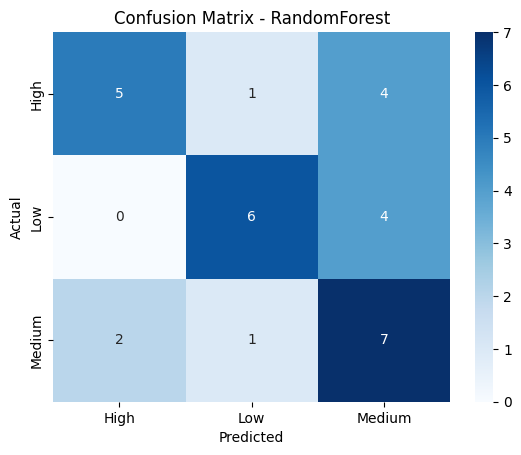

In [34]:
cm = confusion_matrix(y_test, rf_preds, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - RandomForest')
plt.show()

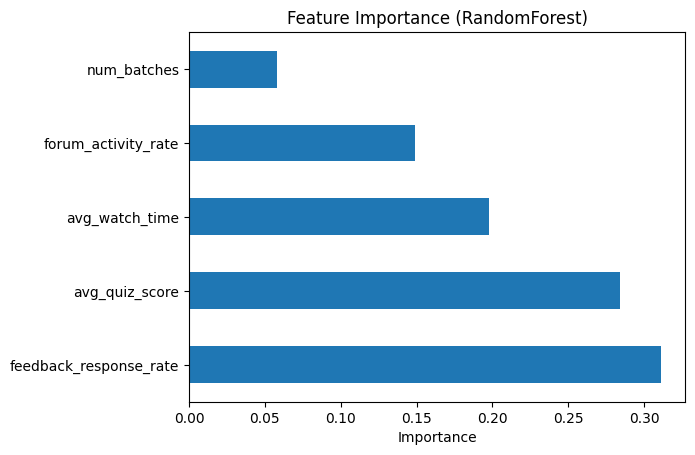

feedback_response_rate    0.311532
avg_quiz_score            0.284102
avg_watch_time            0.197568
forum_activity_rate       0.148940
num_batches               0.057857
dtype: float64


In [36]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind='barh')
plt.title('Feature Importance (RandomForest)')
plt.xlabel('Importance')
plt.show()
print(importances)

#### 1. Which features most influenced instructor effectiveness, and why?

Based on the feature importance from the tuned Random Forest model, the most important features were:

- `feedback_response_rate` (0.31)
- `avg_quiz_score` (0.28)
- `avg_watch_time` (0.20)
- `forum_activity_rate` (0.15)
- `num_batches` (0.06)

The model was trained using features that were not directly used to calculate the `effectiveness_score`, so that we could avoid data leakage.

`avg_quiz_score` being one of the most important features makes sense. It was not used to calculate the effectiveness score, but it is still related to how well students are learning. This suggests that instructor effectiveness may also be reflected in other student performance measures.

Interestingly, `feedback_response_rate` was the most important feature. This measures whether students actually responded to the feedback survey, not whether they gave a high rating. One possible reason is that more engaged students may be more likely to fill out feedback forms. However, this does not mean that a high response rate directly proves that an instructor is better.

`num_batches` had very low importance (0.06). This suggests that the model is not mainly using the number of batches an instructor has taught to predict their effectiveness.


#### 2. Which variables could be misleading or confounded?

Some of the variables can be misleading because they may be affected by factors other than the instructor.

- **`completion_rate`, `avg_score_improvement`, `assignment_submission_rate`, and `avg_feedback_score`** were directly used to calculate the `effectiveness_score`. When we used these same features to predict the score, the model achieved around 97% accuracy. However, this result was misleading because the model was basically learning the same formula that created the target. This is data leakage. After removing these features, accuracy dropped to around 60–63%, which is a more realistic result.

- **`dropout_rate`** is very strongly related to `completion_rate` (correlation ≈ -0.95). Since completion rate is already part of the effectiveness score, using dropout rate can indirectly give the model information about the target as well.

- **`feedback_response_rate`** was the most important feature in the corrected model, but it may not actually represent instructor quality. For example, some courses may have better reminders or survey systems that make students more likely to respond.

- **`avg_quiz_score`** can also be affected by things outside the instructor's control. For example, one instructor may get a batch of students who already have strong academic skills, while another may get a weaker batch. Course difficulty can also affect quiz scores.

- **`num_batches`** could be related to an instructor's experience or seniority. However, its low importance suggests that it is not having a major effect on the model's predictions here.

---

#### 3. How could this model fail in real-world usage?

There are several ways the model could give misleading results:

- **Data leakage:** If we include the features used to create the `effectiveness_score`, the model can achieve very high accuracy simply by learning the formula. This would make the model look much better than it actually is.

- **Relative rather than absolute performance:** The tiers were created using `qcut`, which creates groups of roughly equal size. This means around one-third of instructors will always be in the "Low" group relative to the others. It does not mean that one-third of instructors are actually poor instructors.

- **Small dataset:** We only have 120 instructors, so the results can change depending on the train/test split. The variation between cross-validation folds also shows that the results should be treated as a general indication rather than a final conclusion.

- **Other factors affecting the predictions:** Features such as `avg_quiz_score` and `feedback_response_rate` may be influenced by students, course difficulty, or course design. The model could therefore assign a lower effectiveness level to an instructor because of factors they cannot control.

- **Changes over time:** The model may not work as well in the future if student behaviour, courses, assessments, or the platform changes. The model would need to be checked and retrained regularly.

---

#### 4. What additional data would you want to improve this analysis?

Some additional data could make the analysis much more reliable:

- **Student's starting ability:** Pre-course test scores would help us see how much students improved instead of only looking at their final performance.

- **Course difficulty:** Information about how difficult each course is would help separate the effect of the course from the effect of the instructor.

- **Data from multiple years:** Looking at the same instructors across different semesters or years would help us see whether their performance is consistent over time.

- **Human evaluations:** Feedback from managers, peers, or structured classroom observations could give us another measure of instructor performance.

- **Class size and student information:** These could help explain why some batches have different engagement or performance levels.

- **Actual feedback comments:** Instead of only using the average feedback score, the written comments could give more useful information about what students liked or disliked about an instructor.

---

#### 5. Should this model be used for instructor performance evaluation? Why or why not?

The model should **not be used by itself for important decisions** such as salary, promotion, or termination.

There are a few reasons for this:

- **The accuracy is only moderate:** After removing the leaking features, the model achieved around 60–63% accuracy. This is better than the 33% baseline for three balanced classes, but it is not reliable enough to make important decisions about individual instructors.

- **The tiers are relative:** Because `qcut` creates relative groups, an instructor can be placed in the "Low" group even if the overall performance of all instructors is good.

- **There are confounding factors:** Some important features may be affected by student ability, course difficulty, or survey design rather than the instructor themselves.

- **The dataset is small:** With only 120 instructors, more data would be needed before treating the model as a reliable evaluation system.

A better use of the model would be as a **supporting signal**. For example, it could help identify instructors who may need further review or support. The result should then be looked at together with human feedback, peer reviews, and the context of the course rather than being treated as the final judgment of an instructor's performance.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 2, 3, 5],
    'n_estimators': [50, 100, 200]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs = -1), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 50}
Best CV score: 0.7333333333333334
